# scmidas quickstart

Five lines from `pip install scmidas` to a UMAP of mosaic-integrated single-cell multi-omic data.

**On a free Colab T4 GPU** the entire notebook (install + train + UMAP) runs in roughly 2 minutes. **On a local mid-range GPU** the training step alone is ~1 minute.

This notebook trains MIDAS on a 1600-cell PBMC RNA+ADT mosaic dataset bundled inside the package — no extra downloads, no config files, no data prep.

> ⚠️ **The defaults in `scmidas.integrate()` are tuned for this toy dataset.** They are *not* general-purpose. For a real analysis, override `max_epochs` (1000-2000) and `batch_size` (256). See [demo2 / demo3](https://scmidas.readthedocs.io/en/latest/) for full pipelines.

## 1. Install

Skipped if `scmidas` is already importable (e.g. local Jupyter). On Colab the `pip install` may print a benign "dependency resolver" warning about Colab's pre-pinned `pandas` — this is harmless and doesn't affect the demo.

In [1]:
import importlib.util
if importlib.util.find_spec('scmidas') is None:
    !pip install --quiet scmidas

## 2. Confirm a GPU is available

If you see a warning here, the notebook is running on CPU and training will take ~5-10 minutes instead of ~1 minute. **To enable a GPU on Colab**: `Runtime → Change runtime type → Hardware accelerator → T4 GPU`, then `Runtime → Restart and run all`.

In [2]:
import torch
if torch.cuda.is_available():
    print(f'✓ GPU detected: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU detected. Training will fall back to CPU (~5-10 min).')
    print('   Colab: Runtime → Change runtime type → T4 GPU, then Run all.')

✓ GPU detected: Tesla V100S-PCIE-32GB


## 3. Load and inspect the bundled quickstart dataset

The bundled MuData has 4 batches arranged in the **classic mosaic structure** that MIDAS is built to integrate: one RNA-only batch, one ADT-only batch, and two batches with both modalities.

In [3]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(level=logging.INFO)

import scmidas

mdata = scmidas.datasets.quickstart()

print('Per-batch breakdown:')
for b in sorted(set(mdata['rna'].obs['batch']) | set(mdata['adt'].obs['batch'])):
    n_rna = int((mdata['rna'].obs['batch'] == b).sum())
    n_adt = int((mdata['adt'].obs['batch'] == b).sum())
    mods = ('RNA' if n_rna else '') + ('+' if n_rna and n_adt else '') + ('ADT' if n_adt else '')
    n_cells = max(n_rna, n_adt)
    print(f'  {b}: {n_cells:>4} cells   modalities: {mods:<7}')
print(f'\nTotal: {mdata.n_obs} cells across 4 batches  |  RNA features: {mdata["rna"].n_vars}  |  ADT features: {mdata["adt"].n_vars}')

Per-batch breakdown:
  p1_0:  400 cells   modalities: RNA    
  p2_0:  400 cells   modalities: ADT    
  p3_0:  400 cells   modalities: RNA+ADT
  p4_0:  400 cells   modalities: RNA+ADT

Total: 1600 cells across 4 batches  |  RNA features: 500  |  ADT features: 224


## 4. Train

One call. `scmidas.integrate(...)` infers feature dimensions from the MuData and uses defaults that produce a clean UMAP for this toy dataset in about a minute. (The full `MIDAS` class is still available for users who want explicit control.)

In [4]:
model = scmidas.integrate(mdata)

INFO:scmidas.config:The model is initialized with the default configurations.
INFO:scmidas.api:scmidas.integrate(): toy-tuned defaults — batch_size=128, max_epochs=65, lr=0.0003. For real datasets, override max_epochs (e.g. 2000) and consider batch_size=256.
INFO:scmidas.model:Input data: 
      #CELL   #RNA   #ADT
p1_0    400  500.0    NaN
p2_0    400    NaN  224.0
p3_0    400  500.0  224.0
p4_0    400  500.0  224.0
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=65` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=65` reached.
INFO:scmidas.model:Checkpoint successfully saved to "./saved_models/scmidas/model_epoch65_20260503-074410.pt".


## 5. Compute joint latent embeddings

Stitch the per-batch latent blocks into one (cells × 32) matrix aligned with the MuData.

In [5]:
import numpy as np

out = model.predict(joint_latent=True)

z_c_blocks, all_ids = [], []
for b in ['p1_0', 'p2_0', 'p3_0', 'p4_0']:
    z_c_blocks.append(out[b]['z_c']['joint'])
    in_rna = (mdata['rna'].obs['batch'] == b)
    in_adt = (mdata['adt'].obs['batch'] == b)
    rna_ids = mdata['rna'].obs.index[in_rna].tolist()
    adt_ids = mdata['adt'].obs.index[in_adt].tolist()
    all_ids.extend(rna_ids + [c for c in adt_ids if c not in set(rna_ids)])
z_c = np.vstack(z_c_blocks)

print(f'latent shape: {z_c.shape}')

INFO:scmidas.model:Predicting using device: cuda
INFO:scmidas.model:Processing batch p1_0: ['rna']
predict:p1_0: 100%|██████████| 4/4 [00:00<00:00,  5.64it/s]
INFO:scmidas.model:Processing batch p2_0: ['adt']
predict:p2_0: 100%|██████████| 4/4 [00:00<00:00,  5.37it/s]
INFO:scmidas.model:Processing batch p3_0: ['rna', 'adt']
predict:p3_0: 100%|██████████| 4/4 [00:00<00:00,  5.77it/s]
INFO:scmidas.model:Processing batch p4_0: ['rna', 'adt']
predict:p4_0: 100%|██████████| 4/4 [00:00<00:00,  5.11it/s]

latent shape: (1600, 32)


## 6. UMAP

Color by cell type (left) and source batch (right). MIDAS should produce **lineage-separated clusters** (Mono / CD4 T / CD8 T / NK / B / DC) that **mix freely across batches** — the central promise of mosaic integration.

... storing 'batch' as categorical
... storing 'celltype' as categorical


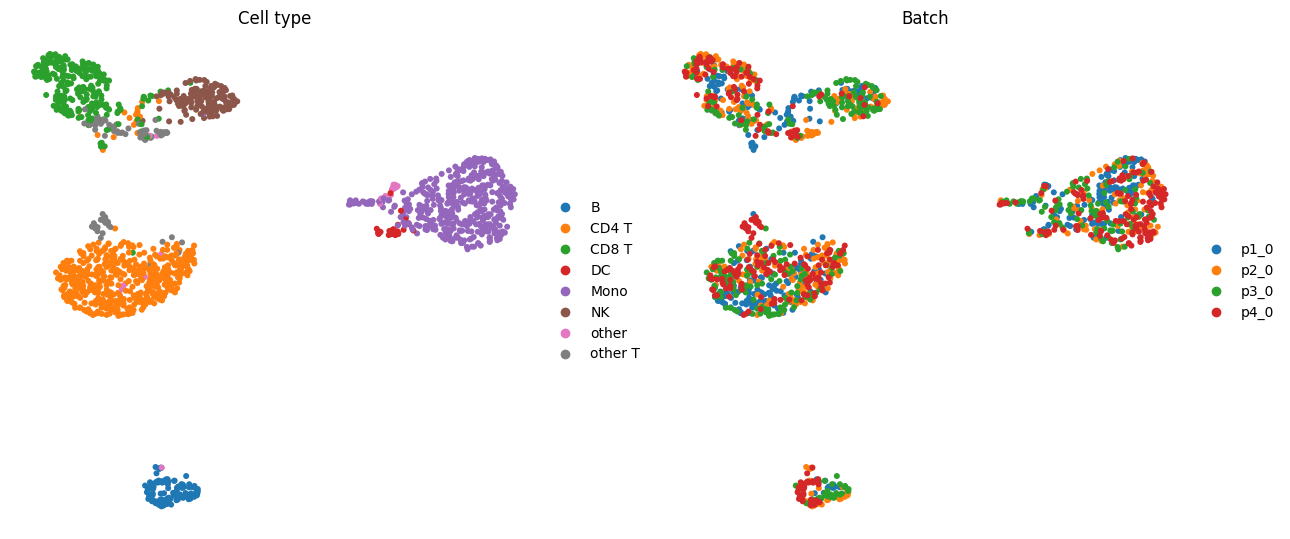

In [6]:
import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc

ad_z = ad.AnnData(X=z_c)
ad_z.obs_names = all_ids
batches, celltypes = [], []
for c in all_ids:
    if c in mdata['rna'].obs_names:
        batches.append(mdata['rna'].obs.loc[c, 'batch'])
        celltypes.append(mdata['rna'].obs.loc[c, 'celltype'])
    else:
        batches.append(mdata['adt'].obs.loc[c, 'batch'])
        celltypes.append(mdata['adt'].obs.loc[c, 'celltype'])
ad_z.obs['batch'] = batches
ad_z.obs['celltype'] = celltypes

sc.pp.neighbors(ad_z, n_neighbors=30)
sc.tl.umap(ad_z, random_state=42, min_dist=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc.pl.umap(ad_z, color='celltype', ax=axes[0], show=False, frameon=False, title='Cell type')
sc.pl.umap(ad_z, color='batch',    ax=axes[1], show=False, frameon=False, title='Batch')
plt.tight_layout()
plt.show()

## Next steps

- See `docs/source/tutorials/basics/` for the full demos (real-sized data, multi-GPU training, prediction tasks like imputation, batch correction, modality translation).
- For your own MuData: `scmidas.integrate(your_mdata, max_epochs=2000, batch_size=256)` (paper-default hyperparameters).